# Foursquare Dataset (Restaurants)

In [366]:
import pandas as pd 

In [368]:
df = pd.read_csv("fullrestaurants_with_google_status_UPDATED.csv")

In [370]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3179 entries, 0 to 3178
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      3179 non-null   object 
 1   Name             3179 non-null   object 
 2   Latitude         3179 non-null   float64
 3   Longitude        3179 non-null   float64
 4   Category         3179 non-null   object 
 5   Rating           3179 non-null   object 
 6   Popularity       3179 non-null   float64
 7   Google Place ID  1720 non-null   object 
 8   Business Status  3179 non-null   object 
 9   Distance (m)     3106 non-null   float64
dtypes: float64(4), object(6)
memory usage: 248.5+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
0,5714be47498ecf6b9306ae3a,Amigo Resturant (مطعم أميغو),26.244824,49.981499,Restaurant,6.6,0.705087,ChIJo9QBI1ceNj4RsKe7bl3dMfI,CLOSED_TEMPORARILY,12.628938
1,53556d0e11d272d79af43d04,KFC (كنتاكي),26.244824,49.981499,Fried Chicken Joint,5.6,0.999678,NaN,NOT FOUND,10870.239677
2,5bb08ac7446ea6002cdbde3c,سكبة,26.245131,49.981418,Restaurant,No rating,0.982188,ChIJuwsGPBofNj4Rmh7HC9TkcC4,OPERATIONAL,34.640068
3,566e5bb4498e8b885036a42e,مطعم حسن ابراهيم الابراهيم,26.245131,49.981418,Restaurant,No rating,0.147715,ChIJFWj_P1ceNj4RwU4ZxISVJI8,OPERATIONAL,17.941597
4,55d2a54e498e49129ce7df99,Alshyokh 2 (مطعم الشيوخ 2),26.245332,49.981542,Fast Food Restaurant,No rating,0.981289,ChIJuyVNQFceNj4Ri7vOGmgaBNY,CLOSED_PERMANENTLY,10.060357


## Check Business Status

In [373]:
#Check business status counts
status_counts_df = df['Business Status'].value_counts().reset_index()
status_counts_df.columns = ['Business Status', 'Count']
print(status_counts_df)

      Business Status  Count
0           NOT FOUND   1459
1         OPERATIONAL   1334
2  CLOSED_PERMANENTLY    332
3  CLOSED_TEMPORARILY     54


In [375]:
#Manual Updates: 
df.loc[df['Business ID'] == '5e26c9bbae47d70007e62a02', 'Business Status'] = 'CLOSED_PERMANENTLY'
df.loc[df['Google Place ID'] == 'ChIJazv0sm3mST4RemnMRzEQes4', 'Category'] = 'Coffee Shop'


#Manual Removal for businesses not found or out of scope
drop_business_byBusinessID = [
    '4f51abefe4b050039cc17929'
]

drop_business_byGoogleID = [
    'ChIJozFd2l_mST4ReTx64ZY08CY',
    'ChIJkU3XnjX-ST4RAsvMvDiOaw4',
    'ChIJVw9sSTb-ST4RbqwEu9EelXM',
    'ChIJFefWNzH-ST4Ruod-zfWb9sc',
    'ChIJJyFmIZD_ST4RwNJMepWvGa8',
    'ChIJ_1t7dJL9ST4RlVeWX45tVww',
    'ChIJu-1zNhP_ST4RtZl2RjbFxlw',
    'ChIJT9eNHbPoST4R4E1dofC2GYs',
]
df = df[~df['Business ID'].isin(drop_business_byBusinessID)]
df = df[~df['Google Place ID'].isin(drop_business_byGoogleID)]

df.info()

#Check business status counts
status_counts_df = df['Business Status'].value_counts().reset_index()
status_counts_df.columns = ['Business Status', 'Count']
print(status_counts_df)

<class 'pandas.core.frame.DataFrame'>
Index: 3162 entries, 0 to 3178
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      3162 non-null   object 
 1   Name             3162 non-null   object 
 2   Latitude         3162 non-null   float64
 3   Longitude        3162 non-null   float64
 4   Category         3162 non-null   object 
 5   Rating           3162 non-null   object 
 6   Popularity       3162 non-null   float64
 7   Google Place ID  1703 non-null   object 
 8   Business Status  3162 non-null   object 
 9   Distance (m)     3089 non-null   float64
dtypes: float64(4), object(6)
memory usage: 271.7+ KB
      Business Status  Count
0           NOT FOUND   1459
1         OPERATIONAL   1317
2  CLOSED_PERMANENTLY    332
3  CLOSED_TEMPORARILY     54


In [377]:
#Drop closed and not found businesses
df_operational = df[~df['Business Status'].isin(['CLOSED_PERMANENTLY', 'CLOSED_TEMPORARILY','NOT FOUND', 'UNKNOWN'])]
df_operational

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
2,5bb08ac7446ea6002cdbde3c,سكبة,26.245131,49.981418,Restaurant,No rating,0.982188,ChIJuwsGPBofNj4Rmh7HC9TkcC4,OPERATIONAL,34.640068
3,566e5bb4498e8b885036a42e,مطعم حسن ابراهيم الابراهيم,26.245131,49.981418,Restaurant,No rating,0.147715,ChIJFWj_P1ceNj4RwU4ZxISVJI8,OPERATIONAL,17.941597
5,5c07ee8f112c6c002c880014,مطعم راكان الشمري البخاري,26.245379,49.981826,Halal Restaurant,No rating,0.996023,ChIJr8MdQVceNj4RLYMLJjQ3NrM,OPERATIONAL,12.206721
11,5fcdf6606fd0767a94aa1185,مطاعم الغرن الذهبي البخاري,26.238366,49.971963,Restaurant,No rating,0.994315,ChIJf-Ur-PseNj4Rz_LobUC-aNE,OPERATIONAL,22.089161
17,5fce0d71939eba37c73ee617,الوحيد,26.235897,49.990139,Middle Eastern Restaurant,No rating,0.996761,ChIJ165XJ-ofNj4R-sI3B7EafwE,OPERATIONAL,82.334679
23,56ea82e6498edfc2496f3171,Silver Tower Restaurant (مطعم ومطبخ البرج الفضي),26.249519,50.199453,Middle Eastern Restaurant,No rating,0.924475,ChIJ1YzMpcDCST4RxxWkhQVnNjc,OPERATIONAL,22.764186
27,5d5e6efa719d570009fa8c53,المضغوط الناضج,26.250151,50.201587,Middle Eastern Restaurant,No rating,0.411267,ChIJe4x0e8DCST4RsvRgKbDrTq0,OPERATIONAL,14.449576
34,561e181f498e3dede4fa6761,Blue Garden (بلو جاردن),26.255244,50.220898,Lebanese Restaurant,8.1,0.982453,ChIJRbM8f7_DST4RRf5n_pah-uU,OPERATIONAL,19.120883
35,63ea568514027f420411ef88,Chef Eyad Smoked Meat,26.255537,50.221155,Steakhouse,7.9,0.966183,ChIJJ2TzfSfDST4Rnb8dGTbr73Y,OPERATIONAL,11.239438
37,5ff075e602475516d835032d,Ocean,26.255244,50.221370,Seafood Restaurant,6.9,0.075462,ChIJcxViI0XDST4R4z8LvkdxPfQ,OPERATIONAL,61.082759


## Check Duplicates

In [380]:
# Check for duplicates in the 'ColumnName'
duplicates = df_operational[df_operational.duplicated(subset=['Google Place ID'], keep=False)]

pd.set_option('display.max_rows', None)
duplicates.info()
# Display duplicates
duplicates


<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 58 to 3172
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      158 non-null    object 
 1   Name             158 non-null    object 
 2   Latitude         158 non-null    float64
 3   Longitude        158 non-null    float64
 4   Category         158 non-null    object 
 5   Rating           158 non-null    object 
 6   Popularity       158 non-null    float64
 7   Google Place ID  158 non-null    object 
 8   Business Status  158 non-null    object 
 9   Distance (m)     158 non-null    float64
dtypes: float64(4), object(6)
memory usage: 13.6+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
58,52a1a65f11d2ab6a996f828e,Shwaiat Al-Khalij (شواية الخليج),26.269443,50.189858,Restaurant,8.8,0.993587,ChIJ_4couAPoST4RmT-QIhwNC5E,OPERATIONAL,8.320197
62,53347813498eaacc9244080c,مطعم مشاوي الغربية للسيريه,26.269952,50.191318,Ethiopian Restaurant,8.1,0.989216,ChIJR3XJBwPoST4RpR82Crchp7U,OPERATIONAL,27.976706
71,5354e240498e5f75d1611123,مطاعم شواية الخليج,26.269075,50.190190,Mediterranean Restaurant,8.9,0.995190,ChIJ_4couAPoST4RmT-QIhwNC5E,OPERATIONAL,44.649733
75,504b6850e4b03dcfecc208f3,مطعم الصقر الذهبي ٢,26.273028,50.194759,Middle Eastern Restaurant,7.0,0.960509,ChIJqcybYBvoST4RpUk_UFMhDzw,OPERATIONAL,16.303132
89,522b4de711d284ab80f94b92,مخبازة الصقر الذهبي,26.273489,50.194756,Middle Eastern Restaurant,5.9,0.948673,ChIJqcybYBvoST4RpUk_UFMhDzw,OPERATIONAL,59.335974
106,4dfbbdcd52b14520b6cf321d,Fawaz Broasted,26.268811,50.213331,Fried Chicken Joint,7.4,0.982941,ChIJhSjcP5vCST4R6Kix1YUHpEA,OPERATIONAL,132.662492
124,5067384ee4b0bb47b20f48b2,بروستد فواز,26.266016,50.213002,Wings Joint,No rating,0.961724,ChIJhSjcP5vCST4R6Kix1YUHpEA,OPERATIONAL,183.398347
145,51053ea9e4b0275f78fb5193,بروستد فواز,26.267751,50.212960,Restaurant,6.5,0.478764,ChIJhSjcP5vCST4R6Kix1YUHpEA,OPERATIONAL,9.519751
162,63b699a8d9e6656328792511,مطعم ألذ طبق,26.284284,50.060532,Pakistani Restaurant,No rating,0.502989,ChIJ58oYduThST4RPpEsem-9XIk,OPERATIONAL,54.119883
163,6219445950798804635b713f,المذاق العالي,26.284708,50.060771,Fast Food Restaurant,No rating,0.993750,ChIJ58oYduThST4RPpEsem-9XIk,OPERATIONAL,2.318677


In [382]:
#sort based google place id to display the same business with different names in the same area 
duplicates = duplicates.sort_values(by='Google Place ID')
duplicates

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
692,617eb36de8f2742f714341bf,المشوى العنابي,26.347159,50.048865,BBQ Joint,8.1,0.978694,ChIJ-xZdYeXjST4RsttlXTXtudE,OPERATIONAL,43.132495
699,617c69baaab3314d5930e9dd,Ennabi Grill,26.347033,50.048477,BBQ Joint,No rating,0.902540,ChIJ-xZdYeXjST4RsttlXTXtudE,OPERATIONAL,14.627544
2328,624049d77c3bc125f089f889,Osmanli Lezzat,26.471723,50.131387,Turkish Restaurant,No rating,0.866543,ChIJ12iGZMX7ST4RwkYM34B_R7o,OPERATIONAL,9.387007
2317,5a774beec876c86006c3d4ee,المذاق العثماني,26.471801,50.131322,Turkish Restaurant,7.4,0.978280,ChIJ12iGZMX7ST4RwkYM34B_R7o,OPERATIONAL,17.818634
2022,510ff156e4b04d5bbd93fcc8,مطعم بابا عبده للأكلات مصريه,26.439397,50.061501,Middle Eastern Restaurant,No rating,0.917592,ChIJ1XvPsI_9ST4RrNSLLV-JQ4k,OPERATIONAL,185.475675
1852,5182301c498e33f3c4ec1abe,Baba Abdu Restaurant,26.439397,50.061501,Falafel Restaurant,No rating,0.940006,ChIJ1XvPsI_9ST4RrNSLLV-JQ4k,OPERATIONAL,185.475675
2440,59dd2a355ba046695ca80d1b,Rawaa Restaurant (مطعم روعة),26.474121,50.124852,Middle Eastern Restaurant,7.2,0.802739,ChIJ1xnJZtz7ST4RTbOmGmFHRyk,OPERATIONAL,74.399443
2468,58ebd8e5375c4a3655ae4841,Rawaa Restaurant,26.474505,50.125165,Comfort Food Restaurant,No rating,0.913306,ChIJ1xnJZtz7ST4RTbOmGmFHRyk,OPERATIONAL,41.475535
2773,631a49a11f843b5d3f5d66d5,احلى تكة في الخبر,26.217495,50.203642,American Restaurant,No rating,0.499605,ChIJ2yecaInDST4RDbdFxgbO7XU,OPERATIONAL,18.565017
2772,631b7ba7772e3566344fa91c,نكهات التكه,26.217389,50.203584,BBQ Joint,No rating,0.898661,ChIJ2yecaInDST4RDbdFxgbO7XU,OPERATIONAL,8.455732


### Map Visualization of Duplicates

   Cluster  Number of Points
0        7                25
1        4                24
2        1                20
3        0                19
4       -1                18
5        5                14
6        6                14
7        2                10
8        3                 8
9        8                 6


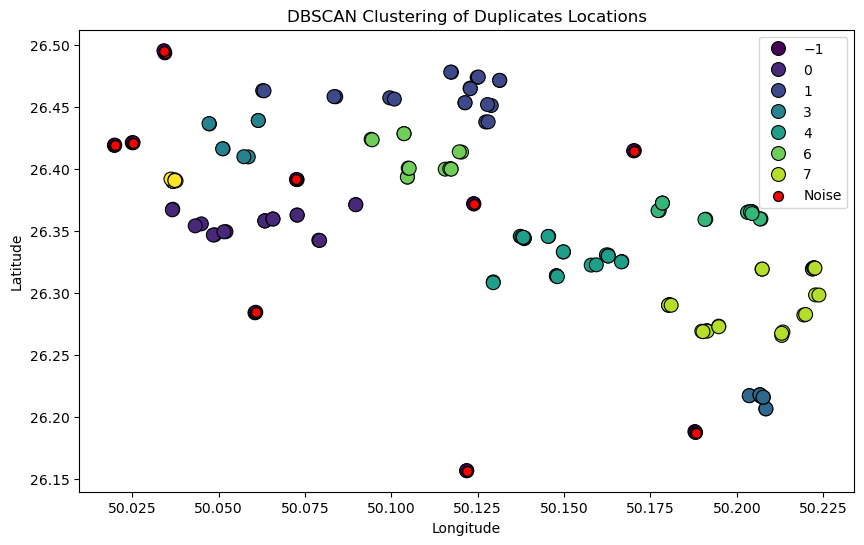

In [385]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.cluster import DBSCAN

# Apply DBSCAN Clustering
dbscan = DBSCAN(eps=0.022, min_samples=5)  #eps was determined based on the 2nd derivative # eps defines the neighborhood size, min_samples defines cluster density
duplicates['Cluster'] = dbscan.fit_predict(duplicates[['Latitude', 'Longitude']])

# Plot DBSCAN Clustering Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=duplicates['Longitude'], y=duplicates['Latitude'], hue=duplicates['Cluster'], palette='viridis', s=100, edgecolor='k')

# Highlight noise points (-1) separately
noise = duplicates[duplicates['Cluster'] == -1]
plt.scatter(noise['Longitude'], noise['Latitude'], color='red', label='Noise', s=50, edgecolors='black')

# Count the number of points in each cluster
cluster_counts = duplicates['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Number of Points']

# Display the count of neighbors per cluster
print(cluster_counts)

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Duplicates Locations")
plt.legend()
plt.show()

In [387]:
cluster_0 = duplicates[duplicates['Cluster'] == 0]
cluster_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 692 to 984
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      19 non-null     object 
 1   Name             19 non-null     object 
 2   Latitude         19 non-null     float64
 3   Longitude        19 non-null     float64
 4   Category         19 non-null     object 
 5   Rating           19 non-null     object 
 6   Popularity       19 non-null     float64
 7   Google Place ID  19 non-null     object 
 8   Business Status  19 non-null     object 
 9   Distance (m)     19 non-null     float64
 10  Cluster          19 non-null     int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 1.8+ KB


In [389]:
import folium
# Define the map centered around the average location
map_center = [cluster_0['Latitude'].mean(), cluster_0['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Assign a color to each cluster
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange'}

# Add markers for each business
for _, row in cluster_0.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Name: {row['Name']}\nPopularity:{row['Popularity']},\nFoursquareID: {row['Business ID']}\nGoogleMapsID: {row['Google Place ID']}\nlat: {row['Latitude']}\nlong:{row['Longitude']}",
        tooltip=f"Name: {row['Name']}",
        icon=folium.Icon(color=cluster_colors.get(row['Cluster'], 'gray'))
    ).add_to(m)

# Display the map
m

m.save("coffee_maps.html")

In [391]:
#manual removal for business that are not duplicates
not_dup_removeBy_GoogleID = [
    
]

not_dup_removeBy_BusinessID = [
    
]
#duplicates = duplicates[~duplicates['Business ID'].isin(not_dup_removeBy_BusinessID)]
#duplicates = duplicates[~duplicates['Google Place ID'].isin(not_dup_removeBy_GoogleID)]

duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 692 to 1331
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      158 non-null    object 
 1   Name             158 non-null    object 
 2   Latitude         158 non-null    float64
 3   Longitude        158 non-null    float64
 4   Category         158 non-null    object 
 5   Rating           158 non-null    object 
 6   Popularity       158 non-null    float64
 7   Google Place ID  158 non-null    object 
 8   Business Status  158 non-null    object 
 9   Distance (m)     158 non-null    float64
 10  Cluster          158 non-null    int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 14.8+ KB


In [393]:
duplicates

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
692,617eb36de8f2742f714341bf,المشوى العنابي,26.347159,50.048865,BBQ Joint,8.1,0.978694,ChIJ-xZdYeXjST4RsttlXTXtudE,OPERATIONAL,43.132495,0
699,617c69baaab3314d5930e9dd,Ennabi Grill,26.347033,50.048477,BBQ Joint,No rating,0.902540,ChIJ-xZdYeXjST4RsttlXTXtudE,OPERATIONAL,14.627544,0
2328,624049d77c3bc125f089f889,Osmanli Lezzat,26.471723,50.131387,Turkish Restaurant,No rating,0.866543,ChIJ12iGZMX7ST4RwkYM34B_R7o,OPERATIONAL,9.387007,1
2317,5a774beec876c86006c3d4ee,المذاق العثماني,26.471801,50.131322,Turkish Restaurant,7.4,0.978280,ChIJ12iGZMX7ST4RwkYM34B_R7o,OPERATIONAL,17.818634,1
2022,510ff156e4b04d5bbd93fcc8,مطعم بابا عبده للأكلات مصريه,26.439397,50.061501,Middle Eastern Restaurant,No rating,0.917592,ChIJ1XvPsI_9ST4RrNSLLV-JQ4k,OPERATIONAL,185.475675,3
1852,5182301c498e33f3c4ec1abe,Baba Abdu Restaurant,26.439397,50.061501,Falafel Restaurant,No rating,0.940006,ChIJ1XvPsI_9ST4RrNSLLV-JQ4k,OPERATIONAL,185.475675,3
2440,59dd2a355ba046695ca80d1b,Rawaa Restaurant (مطعم روعة),26.474121,50.124852,Middle Eastern Restaurant,7.2,0.802739,ChIJ1xnJZtz7ST4RTbOmGmFHRyk,OPERATIONAL,74.399443,1
2468,58ebd8e5375c4a3655ae4841,Rawaa Restaurant,26.474505,50.125165,Comfort Food Restaurant,No rating,0.913306,ChIJ1xnJZtz7ST4RTbOmGmFHRyk,OPERATIONAL,41.475535,1
2773,631a49a11f843b5d3f5d66d5,احلى تكة في الخبر,26.217495,50.203642,American Restaurant,No rating,0.499605,ChIJ2yecaInDST4RDbdFxgbO7XU,OPERATIONAL,18.565017,2
2772,631b7ba7772e3566344fa91c,نكهات التكه,26.217389,50.203584,BBQ Joint,No rating,0.898661,ChIJ2yecaInDST4RDbdFxgbO7XU,OPERATIONAL,8.455732,2


In [395]:
df_operational[df_operational['Google Place ID']=='ChIJv5fzMCv7ST4RVsYwdcVv99k']

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
1724,5684f57d498e3181b5dd4064,The Square Restaurant,26.408616,50.139092,Restaurant,No rating,0.819666,ChIJv5fzMCv7ST4RVsYwdcVv99k,OPERATIONAL,128.155669


In [397]:
# find the max popularity using groupby()

# Find the max popularity per Place ID and store the best record
df_max_popularity = duplicates.loc[duplicates.groupby('Google Place ID')['Popularity'].idxmax()]

# Reset index for clarity
#df_max_popularity = df_max_popularity.reset_index(drop=True)

df_max_popularity.info()
df_max_popularity



<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 692 to 1314
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      77 non-null     object 
 1   Name             77 non-null     object 
 2   Latitude         77 non-null     float64
 3   Longitude        77 non-null     float64
 4   Category         77 non-null     object 
 5   Rating           77 non-null     object 
 6   Popularity       77 non-null     float64
 7   Google Place ID  77 non-null     object 
 8   Business Status  77 non-null     object 
 9   Distance (m)     77 non-null     float64
 10  Cluster          77 non-null     int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 7.2+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
692,617eb36de8f2742f714341bf,المشوى العنابي,26.347159,50.048865,BBQ Joint,8.1,0.978694,ChIJ-xZdYeXjST4RsttlXTXtudE,OPERATIONAL,43.132495,0
2317,5a774beec876c86006c3d4ee,المذاق العثماني,26.471801,50.131322,Turkish Restaurant,7.4,0.978280,ChIJ12iGZMX7ST4RwkYM34B_R7o,OPERATIONAL,17.818634,1
1852,5182301c498e33f3c4ec1abe,Baba Abdu Restaurant,26.439397,50.061501,Falafel Restaurant,No rating,0.940006,ChIJ1XvPsI_9ST4RrNSLLV-JQ4k,OPERATIONAL,185.475675,3
2468,58ebd8e5375c4a3655ae4841,Rawaa Restaurant,26.474505,50.125165,Comfort Food Restaurant,No rating,0.913306,ChIJ1xnJZtz7ST4RTbOmGmFHRyk,OPERATIONAL,41.475535,1
2772,631b7ba7772e3566344fa91c,نكهات التكه,26.217389,50.203584,BBQ Joint,No rating,0.898661,ChIJ2yecaInDST4RDbdFxgbO7XU,OPERATIONAL,8.455732,2
163,6219445950798804635b713f,المذاق العالي,26.284708,50.060771,Fast Food Restaurant,No rating,0.993750,ChIJ58oYduThST4RPpEsem-9XIk,OPERATIONAL,2.318677,-1
1169,5b533ba9ad1789002c387bfc,BRIO Sandwiches,26.371607,50.089702,Sandwich Spot,7.7,0.912488,ChIJ5RgNo0LjST4Rf8POWTOx4dE,OPERATIONAL,25.971106,0
1809,5de7c8ea1e060900080c6f8a,Meltzone,26.436920,50.047232,Burger Joint,No rating,0.933919,ChIJ61r5zfb9ST4RtVg8FN2gklc,OPERATIONAL,14.256020,3
728,5b30cdc886bc49002c0976f8,Tokuzō (توكوزو),26.345862,50.145384,Japanese Restaurant,8.5,0.983974,ChIJ9etwNbTlST4RQntAyYXlJ44,OPERATIONAL,19.146845,4
187,4bb5dbfe6edc76b07915301c,Fuddruckers (فدركرز),26.290354,50.180236,Burger Joint,9.0,0.971882,ChIJ9yxWRtjnST4RLVtFDmaRgJo,OPERATIONAL,28.866347,7


## Checking df_operational excluding duplicates dataframe

In [400]:
# Subtract df_subset from df_main (remove matching rows)
df_result = df_operational.merge(duplicates, how='left', indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])
df_result.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1159 entries, 0 to 1316
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      1159 non-null   object 
 1   Name             1159 non-null   object 
 2   Latitude         1159 non-null   float64
 3   Longitude        1159 non-null   float64
 4   Category         1159 non-null   object 
 5   Rating           1159 non-null   object 
 6   Popularity       1159 non-null   float64
 7   Google Place ID  1159 non-null   object 
 8   Business Status  1159 non-null   object 
 9   Distance (m)     1159 non-null   float64
 10  Cluster          0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 108.7+ KB


In [402]:
df_result

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
0,5bb08ac7446ea6002cdbde3c,سكبة,26.245131,49.981418,Restaurant,No rating,0.982188,ChIJuwsGPBofNj4Rmh7HC9TkcC4,OPERATIONAL,34.640068,NaN
1,566e5bb4498e8b885036a42e,مطعم حسن ابراهيم الابراهيم,26.245131,49.981418,Restaurant,No rating,0.147715,ChIJFWj_P1ceNj4RwU4ZxISVJI8,OPERATIONAL,17.941597,NaN
2,5c07ee8f112c6c002c880014,مطعم راكان الشمري البخاري,26.245379,49.981826,Halal Restaurant,No rating,0.996023,ChIJr8MdQVceNj4RLYMLJjQ3NrM,OPERATIONAL,12.206721,NaN
3,5fcdf6606fd0767a94aa1185,مطاعم الغرن الذهبي البخاري,26.238366,49.971963,Restaurant,No rating,0.994315,ChIJf-Ur-PseNj4Rz_LobUC-aNE,OPERATIONAL,22.089161,NaN
4,5fce0d71939eba37c73ee617,الوحيد,26.235897,49.990139,Middle Eastern Restaurant,No rating,0.996761,ChIJ165XJ-ofNj4R-sI3B7EafwE,OPERATIONAL,82.334679,NaN
5,56ea82e6498edfc2496f3171,Silver Tower Restaurant (مطعم ومطبخ البرج الفضي),26.249519,50.199453,Middle Eastern Restaurant,No rating,0.924475,ChIJ1YzMpcDCST4RxxWkhQVnNjc,OPERATIONAL,22.764186,NaN
6,5d5e6efa719d570009fa8c53,المضغوط الناضج,26.250151,50.201587,Middle Eastern Restaurant,No rating,0.411267,ChIJe4x0e8DCST4RsvRgKbDrTq0,OPERATIONAL,14.449576,NaN
7,561e181f498e3dede4fa6761,Blue Garden (بلو جاردن),26.255244,50.220898,Lebanese Restaurant,8.1,0.982453,ChIJRbM8f7_DST4RRf5n_pah-uU,OPERATIONAL,19.120883,NaN
8,63ea568514027f420411ef88,Chef Eyad Smoked Meat,26.255537,50.221155,Steakhouse,7.9,0.966183,ChIJJ2TzfSfDST4Rnb8dGTbr73Y,OPERATIONAL,11.239438,NaN
9,5ff075e602475516d835032d,Ocean,26.255244,50.221370,Seafood Restaurant,6.9,0.075462,ChIJcxViI0XDST4R4z8LvkdxPfQ,OPERATIONAL,61.082759,NaN


In [404]:
#Clean df_result from non-food businesses/ retaurants/ or does not exist
not_business_removeBy_BusinessID = [
   '59089ae95d891b37234c78cb',
    '4d5268f8d7eaa143fbdd7d0f',
    '4bb49541f038a593fe29daf0',
    '62ef78b4f004567ed4811f71',
    '5af402cd3ba767002cbad9e7',
    '50b5dd9ae4b033ea1fa2659c',
    '5069bf45e4b064a76e01617d',
    '5d47521a50c12d00096b0ea8',
    '59fa4ccd646e38321387adf9',
    '4c30d2f416adc928c2b6bf9c',
    '61fd6b25c38da312e4e70d09',
    '50ddb5d1e4b09888b52963c9',
    '60e15b4428a58a3f07cb9c50',
    '56bcc11238fa4005fe6ba8db',
    '4de6b319e4cd3c7f89d86f7c',
    
    
    
    
    
]

df_result = df_result[~df_result['Business ID'].isin(not_business_removeBy_BusinessID)]
df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, 0 to 1316
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      1144 non-null   object 
 1   Name             1144 non-null   object 
 2   Latitude         1144 non-null   float64
 3   Longitude        1144 non-null   float64
 4   Category         1144 non-null   object 
 5   Rating           1144 non-null   object 
 6   Popularity       1144 non-null   float64
 7   Google Place ID  1144 non-null   object 
 8   Business Status  1144 non-null   object 
 9   Distance (m)     1144 non-null   float64
 10  Cluster          0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 107.2+ KB


## Final Dataset (df_result + max popularity from duplicated rows )

In [413]:
# Concatenate along rows (axis=0)

df_res = pd.concat([df_result, df_max_popularity], ignore_index=True)

df_res.info()
df_res

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      1221 non-null   object 
 1   Name             1221 non-null   object 
 2   Latitude         1221 non-null   float64
 3   Longitude        1221 non-null   float64
 4   Category         1221 non-null   object 
 5   Rating           1221 non-null   object 
 6   Popularity       1221 non-null   float64
 7   Google Place ID  1221 non-null   object 
 8   Business Status  1221 non-null   object 
 9   Distance (m)     1221 non-null   float64
 10  Cluster          77 non-null     float64
dtypes: float64(5), object(6)
memory usage: 105.1+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
0,5bb08ac7446ea6002cdbde3c,سكبة,26.245131,49.981418,Restaurant,No rating,0.982188,ChIJuwsGPBofNj4Rmh7HC9TkcC4,OPERATIONAL,34.640068,NaN
1,566e5bb4498e8b885036a42e,مطعم حسن ابراهيم الابراهيم,26.245131,49.981418,Restaurant,No rating,0.147715,ChIJFWj_P1ceNj4RwU4ZxISVJI8,OPERATIONAL,17.941597,NaN
2,5c07ee8f112c6c002c880014,مطعم راكان الشمري البخاري,26.245379,49.981826,Halal Restaurant,No rating,0.996023,ChIJr8MdQVceNj4RLYMLJjQ3NrM,OPERATIONAL,12.206721,NaN
3,5fcdf6606fd0767a94aa1185,مطاعم الغرن الذهبي البخاري,26.238366,49.971963,Restaurant,No rating,0.994315,ChIJf-Ur-PseNj4Rz_LobUC-aNE,OPERATIONAL,22.089161,NaN
4,5fce0d71939eba37c73ee617,الوحيد,26.235897,49.990139,Middle Eastern Restaurant,No rating,0.996761,ChIJ165XJ-ofNj4R-sI3B7EafwE,OPERATIONAL,82.334679,NaN
5,56ea82e6498edfc2496f3171,Silver Tower Restaurant (مطعم ومطبخ البرج الفضي),26.249519,50.199453,Middle Eastern Restaurant,No rating,0.924475,ChIJ1YzMpcDCST4RxxWkhQVnNjc,OPERATIONAL,22.764186,NaN
6,5d5e6efa719d570009fa8c53,المضغوط الناضج,26.250151,50.201587,Middle Eastern Restaurant,No rating,0.411267,ChIJe4x0e8DCST4RsvRgKbDrTq0,OPERATIONAL,14.449576,NaN
7,561e181f498e3dede4fa6761,Blue Garden (بلو جاردن),26.255244,50.220898,Lebanese Restaurant,8.1,0.982453,ChIJRbM8f7_DST4RRf5n_pah-uU,OPERATIONAL,19.120883,NaN
8,63ea568514027f420411ef88,Chef Eyad Smoked Meat,26.255537,50.221155,Steakhouse,7.9,0.966183,ChIJJ2TzfSfDST4Rnb8dGTbr73Y,OPERATIONAL,11.239438,NaN
9,5ff075e602475516d835032d,Ocean,26.255244,50.221370,Seafood Restaurant,6.9,0.075462,ChIJcxViI0XDST4R4z8LvkdxPfQ,OPERATIONAL,61.082759,NaN


In [419]:
print("Total number of restaurants = ", len(df_res))

Total number of restaurants =  1221


In [415]:
df_res = df_res.drop('Cluster', axis=1)
df_res[df_res.duplicated(subset=['Business ID'], keep=False)]
df_res[df_res.duplicated(subset=['Google Place ID'], keep=False)]

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)


In [417]:
df_res.to_csv("final_restaurants_dataset_cleaned.csv", index=False, encoding="utf-8-sig")